# NA Inversion Example (updated physics)

This notebook demonstrates kinematic inversion using the Neighbourhood Algorithm (NA) with the updated physical implementation:

$$M_0 = \mu(z) \times A \times slip$$

**Workflow:**
1. Load configuration and forward model
2. Generate controlled synthetic observed waveforms from a 7-parameter ellipse model
3. Run NA search
4. Analyze best model and compare $M_0$/$M_w$
5. Visualize convergence and export results

**Parameters inverted:**
- a1, a2: Ellipse semi-axes (km)
- theta: Rotation angle (x π)
- np, tp: Center position
- dmax: Maximum slip (m)
- vr: Rupture velocity (km/s)

In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'kdellipspy').exists():
            return p
    raise FileNotFoundError('No se encontro PROJECT_ROOT con carpeta kdellipspy.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
KIN_ROOT = PROJECT_ROOT / 'Kinematic_inversion'
INPUT_CTL = KIN_ROOT / 'input.ctl'
AXITRA_DIR = PROJECT_ROOT / 'kdellipspy' / 'AXITRA2024'

if not INPUT_CTL.exists():
    raise FileNotFoundError(f'No se encontro input.ctl en {INPUT_CTL}')
if not AXITRA_DIR.exists():
    raise FileNotFoundError(f'No se encontro AXITRA2024 en {AXITRA_DIR}')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from kdellipspy.config_parser import ConfigParser
from kdellipspy.forward_model import AxitraForwardModel
from kdellipspy.inversion_na import NAInversionModel, NAConfig
from kdellipspy.graphics_suite import GraphicsSuite

# Compatibilidad con celdas existentes
root = KIN_ROOT
input_ctl = INPUT_CTL

✓ All imports successful


## Step 1: Load configuration

In [8]:
input_ctl = root / 'input.ctl'

cfg = ConfigParser(str(input_ctl))
print(f"✓ Loaded configuration from {input_ctl}")
print(f"\nInversion parameters (from input.ctl):")
for i, param in enumerate(cfg.inversion_params.parameters, 1):
    status = "INVERT" if param.flag else "FIXED"
    print(f"  {i}. {param.name:30s} [{param.min_val:8.3f}, {param.max_val:8.3f}] {status}")

print(f"\nInversion process parameters:")
print(f"  Algorithm: {'NA' if cfg.inversion_process.algorithm_type == 0 else 'MC'}")
print(f"  Iterations: {cfg.inversion_process.num_iterations}")
print(f"  Initial samples: {cfg.inversion_process.ss1}")
print(f"  Iteration samples: {cfg.inversion_process.ss_other}")
print(f"  Resample cells: {cfg.inversion_process.cells_resample}")

✓ Loaded configuration from /home/alex/elliptical-rupture-updated/Kinematic_inversion/input.ctl

Inversion parameters (from input.ctl):
  1. Length of axis 1                 (km) [   5.000,   10.000] INVERT
  2. Length of axis 2                 (km) [   5.000,   10.000] INVERT
  3. Rotation angle                 (x pi) [   0.000,    2.000] INVERT
  4. Position of the center np      [   0.000,    1.000] INVERT
  5. Position of the center tp     (x 2pi) [   0.000,    1.000] INVERT
  6. Maximum slip (Dmax)               (m) [   1.000,    3.000] INVERT
  7. Rupture velocity (Vr)          (km/s) [   0.500,    3.500] INVERT

Inversion process parameters:
  Algorithm: NA
  Iterations: 10
  Initial samples: 100
  Iteration samples: 30
  Resample cells: 7


## Step 2: Create controlled synthetic observed data (physical benchmark)

This synthetic benchmark is designed to make NA convergence easy to inspect:
- deterministic random seed,
- low additive noise,
- true model sampled from inversion bounds,
- waveform generation with the full ellipse mapping and physical moment scaling.

In [9]:
# Generate a controlled synthetic dataset for convergence diagnostics
fm = AxitraForwardModel(str(input_ctl), axitra_dir=str(root / 'AXITRA2024'))

# Deterministic seed for reproducibility
rng = np.random.default_rng(20260416)

# Build a true model inside configured bounds (midpoint + small controlled offsets)
param_bounds = np.array([[p.min_val, p.max_val] for p in cfg.inversion_params.parameters], dtype=float)
true_model = param_bounds.mean(axis=1)
true_model[2] = np.clip(0.35, param_bounds[2, 0], param_bounds[2, 1])  # theta
true_model[3] = np.clip(0.45, param_bounds[3, 0], param_bounds[3, 1])  # np
true_model[4] = np.clip(0.20, param_bounds[4, 0], param_bounds[4, 1])  # tp
true_model[6] = np.clip(2.35, param_bounds[6, 0], param_bounds[6, 1])  # vr

# Build geometry with full ellipse mapping and compute scalar moment metrics
geom_true = fm.build_geometry_with_ellipse_slip(true_model)
m0_true, mw_true = fm.estimate_total_moment_and_mw(true_model, geometry=geom_true)

ap = None
try:
    ap = fm.build_axitra(geom_true, latlon=False, freesurface=True)
    ap = fm.green(ap, quiet=True)
    t, sx, sy, sz = fm.conv(ap, geom_true, source_type=1, t0=float(cfg.ellipse.t0), quiet=True)
finally:
    if ap is not None:
        try:
            ap.clean()
        except Exception:
            pass

# Add low-amplitude Gaussian noise
noise_level = 0.002
sx_noisy = sx + noise_level * rng.standard_normal(sx.shape)
sy_noisy = sy + noise_level * rng.standard_normal(sy.shape)
sz_noisy = sz + noise_level * rng.standard_normal(sz.shape)

# Format as (n_stations, n_components, n_samples)
observed_waveforms = np.array([sx_noisy, sy_noisy, sz_noisy])
observed_waveforms = np.transpose(observed_waveforms, (1, 2, 0))
observed_waveforms = np.transpose(observed_waveforms, (0, 2, 1))

print("✓ Generated controlled synthetic observed data")
print(f"  Shape: {observed_waveforms.shape} (n_stations, n_components, n_samples)")
print(f"  Time: {t[0]:.3f} - {t[-1]:.3f} s")
print(f"  Noise level (std): {noise_level}")
print(f"  True M0 [N.m]: {m0_true:.6e}")
print(f"  True Mw: {mw_true:.4f}")
print("\nTrue model used for benchmark:")
for name, value in zip([p.name for p in cfg.inversion_params.parameters], true_model):
    print(f"  {name:20s} = {value:8.3f}")

✓ Generated controlled synthetic observed data
  Shape: (10, 3, 512) (n_stations, n_components, n_samples)
  Time: 0.000 - 127.750 s
  Noise level (std): 0.002
  True M0 [N.m]: 1.826097e+19
  True Mw: 6.7743

True model used for benchmark:
  Length of axis 1                 (km) =    7.500
  Length of axis 2                 (km) =    7.500
  Rotation angle                 (x pi) =    0.350
  Position of the center np =    0.450
  Position of the center tp     (x 2pi) =    0.200
  Maximum slip (Dmax)               (m) =    2.000
  Rupture velocity (Vr)          (km/s) =    2.350


## Step 3: Initialize inversion model

In [10]:
inversion = NAInversionModel(
    str(input_ctl),
    axitra_dir=str(root / 'AXITRA2024'),
    observed_waveforms=observed_waveforms,
    time_array=t,
)

print("✓ NAInversionModel initialized")

✓ NAInversionModel initialized


## Step 4: Run NA search (configured to show convergence clearly)

This setup balances speed and visibility of progress:
- enough evaluations to show improvement trends,
- reproducible random seed,
- `n_samples_iteration` divisible by `n_cells_resample` (neighpy-safe).

In [18]:
# Configure NA search for a clearer synthetic convergence example
na_config = NAConfig(
    n_samples_initial=30,
    n_samples_iteration=30,
    n_iterations=70,
    n_cells_resample=7,
    random_seed=20260416,
)

print("Starting NA search with neighpy...")
print("Synthetic benchmark mode: reproducible seed + low-noise target")
print(f"Expected evaluations ≈ {na_config.n_samples_initial + na_config.n_samples_iteration * na_config.n_iterations}\n")

na_result = inversion.run_na_search(na_config)

print("\n✓ NA search completed")
print(f"Models evaluated: {len(na_result.all_models)}")
# INVERSION PROCESS PARAMETERS: (Algorithm type (NA=0 or MC=1); Number of iterations; 
# Sample size for first iteration; Sample size for other iterations; cells to resample)
# 0 70 30 30 7

Starting NA search with neighpy...
Synthetic benchmark mode: reproducible seed + low-noise target
Expected evaluations ≈ 2130

[NA] Adjusting n_samples_iteration from 30 to 35 to satisfy neighpy constraint (multiple of n_cells_resample=7).
[NA] Starting search: ni=30, ns=35, n=70, nr=7 -> expected evaluations=2480


NAI - Initial Random Search
[NA] iter=000 eval=00001 misfit=1.045659e+00 best=1.045659e+00
[NA] iter=000 eval=00002 misfit=7.904776e-01 best=7.904776e-01
[NA] iter=000 eval=00003 misfit=1.593352e+00 best=7.904776e-01
[NA] iter=000 eval=00004 misfit=1.325781e+00 best=7.904776e-01
[NA] iter=000 eval=00005 misfit=1.023972e+00 best=7.904776e-01
[NA] iter=000 eval=00006 misfit=1.322290e+00 best=7.904776e-01
[NA] iter=000 eval=00007 misfit=1.305919e+00 best=7.904776e-01
[NA] iter=000 eval=00008 misfit=2.565902e+00 best=7.904776e-01
[NA] iter=000 eval=00009 misfit=1.500339e+00 best=7.904776e-01
[NA] iter=000 eval=00010 misfit=3.401912e+00 best=7.904776e-01
[NA] iter=000 eval=00011 misfit=1.893129e+00 best=7.904776e-01
[NA] iter=000 eval=00012 misfit=1.304928e+00 best=7.904776e-01
[NA] iter=000 eval=00013 misfit=2.449981e+00 best=7.904776e-01
[NA] iter=000 eval=00014 misfit=1.919367e+00 best=7.904776e-01
[NA] iter=000 eval=00015 misfit=3.060277e+00 best=7.904776e-01
[NA] iter=000 eval=00016 mi

NAI - Optimisation Loop:   0%|          | 0/70 [00:00<?, ?it/s]

[NA] iter=001 eval=00031 misfit=1.583282e+00 best=7.904776e-01
[NA] iter=001 eval=00032 misfit=1.639816e+00 best=7.904776e-01
[NA] iter=001 eval=00033 misfit=1.458464e+00 best=7.904776e-01
[NA] iter=001 eval=00034 misfit=1.715993e+00 best=7.904776e-01
[NA] iter=001 eval=00035 misfit=8.561362e-01 best=7.904776e-01
[NA] iter=001 eval=00036 misfit=1.040747e+00 best=7.904776e-01
[NA] iter=001 eval=00037 misfit=8.248565e-01 best=7.904776e-01
[NA] iter=001 eval=00038 misfit=1.039981e+00 best=7.904776e-01
[NA] iter=001 eval=00039 misfit=1.222238e+00 best=7.904776e-01
[NA] iter=001 eval=00040 misfit=1.274233e+00 best=7.904776e-01
[NA] iter=001 eval=00041 misfit=1.260195e+00 best=7.904776e-01
[NA] iter=001 eval=00042 misfit=1.134938e+00 best=7.904776e-01
[NA] iter=001 eval=00043 misfit=8.796294e-01 best=7.904776e-01
[NA] iter=001 eval=00044 misfit=1.079646e+00 best=7.904776e-01
[NA] iter=001 eval=00045 misfit=1.152463e+00 best=7.904776e-01
[NA] iter=001 eval=00046 misfit=1.394461e+00 best=7.904

NAI - Optimisation Loop:   1%|▏         | 1/70 [00:13<15:52, 13.80s/it]

...

[NA] iter=069 eval=02411 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02412 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02413 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02414 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02415 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02416 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02417 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02418 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02419 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02420 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02421 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02422 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02423 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02424 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02425 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=069 eval=02426 misfit=3.649308e-01 best=3.649

NAI - Optimisation Loop:  99%|█████████▊| 69/70 [28:59<00:24, 24.30s/it]

[NA] iter=070 eval=02446 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02447 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02448 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02449 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02450 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02451 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02452 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02453 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02454 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02455 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02456 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02457 misfit=3.649308e-01 best=3.649248e-01
[NA] iter=070 eval=02458 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02459 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02460 misfit=3.649248e-01 best=3.649248e-01
[NA] iter=070 eval=02461 misfit=3.649248e-01 best=3.649

NAI - Optimisation Loop: 100%|██████████| 70/70 [29:26<00:00, 25.24s/it]


✓ NA search completed
Models evaluated: 2480


## Step 5: Analyze results

In [11]:
# Get best model
best_model = na_result.best_model
best_model_vector = np.asarray(best_model.model, dtype=float)
m0_best, mw_best = inversion.fm.estimate_total_moment_and_mw(best_model_vector)

print(f"\nBest model found:")
print(f"  Misfit: {best_model.misfit:.6e}")
print(f"  Iteration: {best_model.iteration}")
print(f"\nParameters:")
for name, value in zip(inversion.param_names, best_model.model):
    print(f"  {name:20s} = {value:8.3f}")

print(f"\nTrue model (for reference):")
for name, value in zip(inversion.param_names, true_model):
    print(f"  {name:20s} = {value:8.3f}")

print("\nMoment comparison:")
print(f"  True M0 [N.m]: {m0_true:.6e}")
print(f"  Best M0 [N.m]: {m0_best:.6e}")
print(f"  True Mw      : {mw_true:.4f}")
print(f"  Best Mw      : {mw_best:.4f}")
print(f"  |Mw error|   : {abs(mw_best - mw_true):.4f}")

vr_true = float(true_model[6])
vr_best = float(best_model.model[6])
print(f"\nRupture velocity error:")
print(f"  true vr: {vr_true:.4f} km/s")
print(f"  best vr: {vr_best:.4f} km/s")
print(f"  abs error: {abs(vr_best - vr_true):.4f} km/s")

NameError: name 'na_result' is not defined

## Step 6: Visualize convergence diagnostics

Besides the standard NA plot, we inspect:
- best-so-far misfit vs evaluation,
- rupture-velocity exploration vs evaluation,
- absolute $M_w$ error vs evaluation.

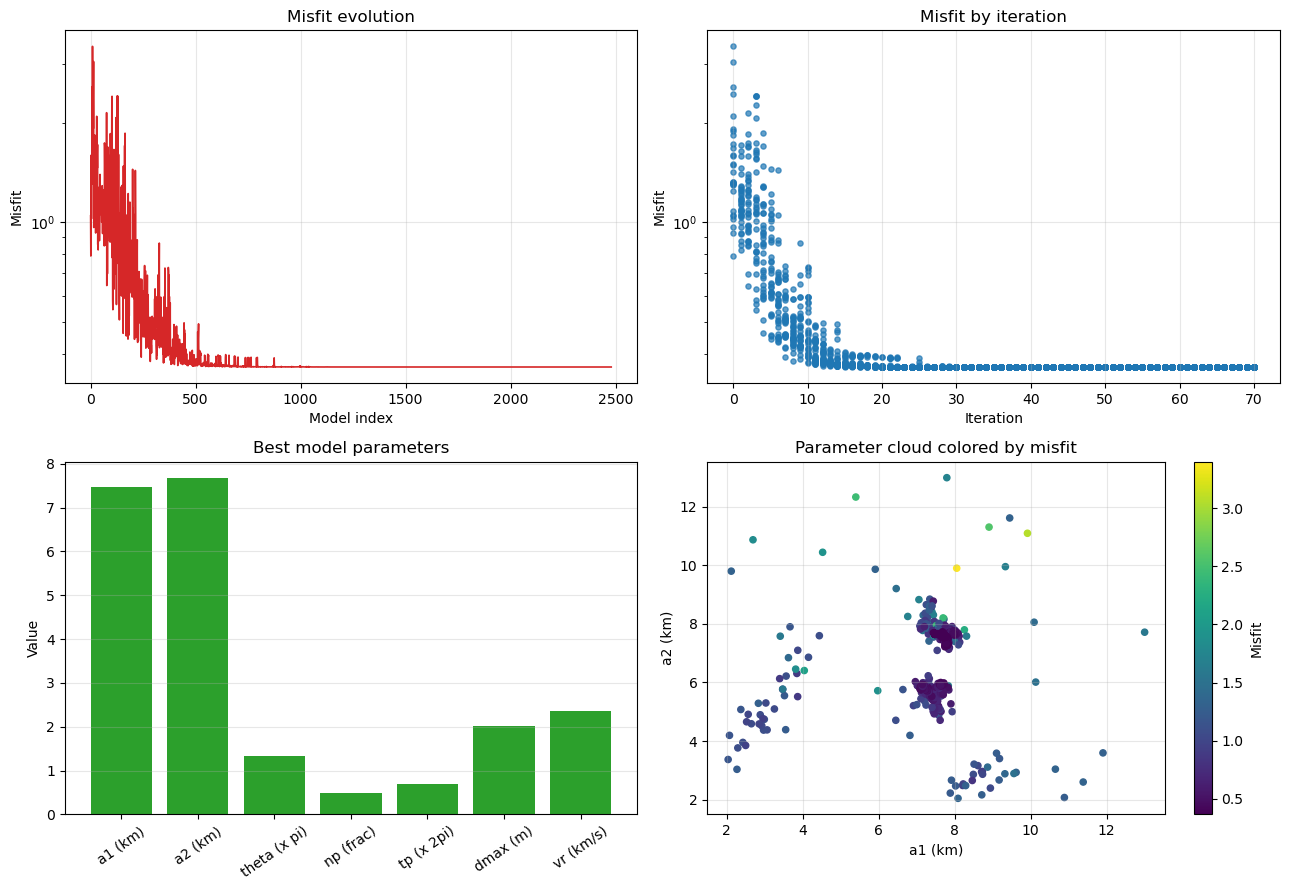

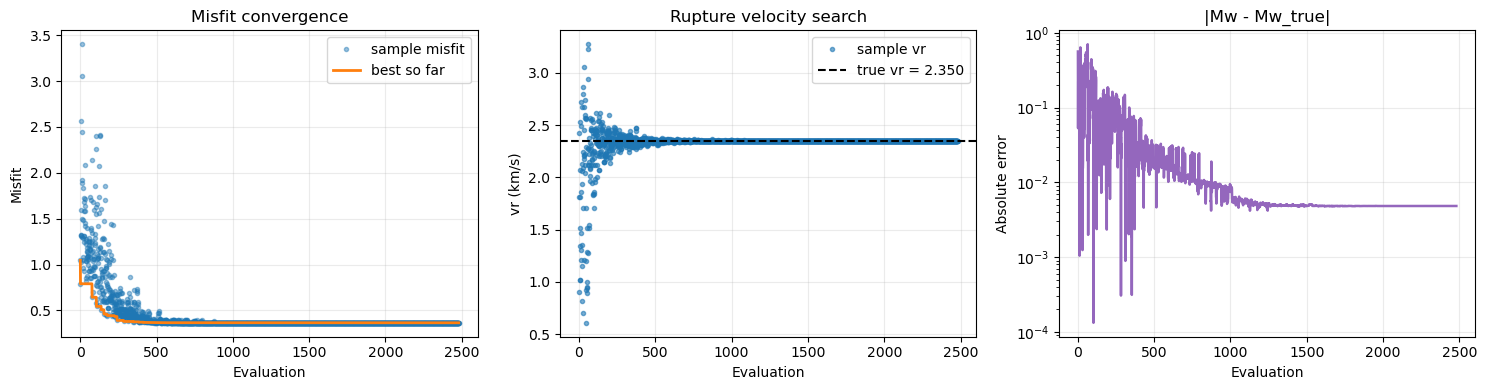

Total models evaluated: 2480
Best misfit: 3.649248e-01
Initial best misfit (first 5 evals): 7.904776e-01
Best |Mw-Mw_true|: 0.0001

Best misfit by iteration:
  iter 00: 7.904776e-01
  iter 01: 8.248565e-01
  iter 02: 6.436185e-01
  iter 03: 5.440377e-01
  iter 04: 4.614330e-01
  iter 05: 4.432520e-01
  iter 06: 4.332039e-01
  iter 07: 3.908894e-01
  iter 08: 3.794379e-01
  iter 09: 3.851936e-01
  iter 10: 3.755852e-01
  iter 11: 3.714722e-01
  iter 12: 3.687515e-01
  iter 13: 3.684852e-01
  iter 14: 3.672067e-01
  iter 15: 3.661890e-01
  iter 16: 3.659051e-01
  iter 17: 3.661340e-01
  iter 18: 3.657564e-01
  iter 19: 3.655240e-01
  iter 20: 3.653050e-01
  iter 21: 3.652584e-01
  iter 22: 3.652096e-01
  iter 23: 3.651160e-01
  iter 24: 3.650399e-01
  iter 25: 3.651732e-01
  iter 26: 3.651023e-01
  iter 27: 3.650122e-01
  iter 28: 3.649926e-01
  iter 29: 3.649975e-01
  iter 30: 3.649684e-01
  iter 31: 3.649660e-01
  iter 32: 3.649597e-01
  iter 33: 3.649527e-01
  iter 34: 3.649581e-01
  

In [20]:
# Visualize results with the unified graphics suite
graphics = GraphicsSuite(base_dir=root, show=True)
graphics.plot_na_results(na_result)

# Build convergence diagnostics arrays
misfits = np.array([m.misfit for m in na_result.all_models], dtype=float)
vr_values = np.array([m.model[6] for m in na_result.all_models], dtype=float)
iterations = np.array([m.iteration for m in na_result.all_models], dtype=int)
evals = np.arange(1, len(misfits) + 1)

best_so_far = np.minimum.accumulate(misfits)
vr_true = float(true_model[6])
vr_abs_error = np.abs(vr_values - vr_true)

# Compute Mw for each sampled model
mw_values = np.empty(len(na_result.all_models), dtype=float)
for i, model_info in enumerate(na_result.all_models):
    _, mw_i = inversion.fm.estimate_total_moment_and_mw(np.asarray(model_info.model, dtype=float))
    mw_values[i] = mw_i
mw_abs_error = np.abs(mw_values - float(mw_true))

# Best misfit per iteration
iter_ids = np.unique(iterations)
best_by_iter = np.array([misfits[iterations == it].min() for it in iter_ids])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(evals, misfits, '.', alpha=0.45, label='sample misfit')
ax[0].plot(evals, best_so_far, '-', lw=2, label='best so far')
ax[0].set_title('Misfit convergence')
ax[0].set_xlabel('Evaluation')
ax[0].set_ylabel('Misfit')
ax[0].legend()
ax[0].grid(alpha=0.25)

ax[1].plot(evals, vr_values, '.', alpha=0.6, label='sample vr')
ax[1].axhline(vr_true, color='k', linestyle='--', label=f'true vr = {vr_true:.3f}')
ax[1].set_title('Rupture velocity search')
ax[1].set_xlabel('Evaluation')
ax[1].set_ylabel('vr (km/s)')
ax[1].legend()
ax[1].grid(alpha=0.25)

ax[2].semilogy(evals, mw_abs_error + 1e-12, '-', lw=1.8, color='tab:purple')
ax[2].set_title('|Mw - Mw_true|')
ax[2].set_xlabel('Evaluation')
ax[2].set_ylabel('Absolute error')
ax[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Total models evaluated: {len(na_result.all_models)}")
print(f"Best misfit: {best_so_far[-1]:.6e}")
print(f"Initial best misfit (first 5 evals): {best_so_far[min(4, len(best_so_far)-1)]:.6e}")
print(f"Best |Mw-Mw_true|: {mw_abs_error.min():.4f}")

print("\nBest misfit by iteration:")
for it, val in zip(iter_ids, best_by_iter):
    print(f"  iter {it:02d}: {val:.6e}")

improvement = (best_so_far[0] - best_so_far[-1]) / max(best_so_far[0], 1e-12)
print(f"\nRelative improvement from first evaluation: {100*improvement:.2f}%")

## Step 7: Export results

In [ ]:
# Export results to JSON and CSV
output_dir = root / 'examples' / 'output'
output_dir.mkdir(parents=True, exist_ok=True)

json_path = output_dir / 'na_results.json'
csv_path = output_dir / 'na_results.csv'
summary_path = output_dir / 'na_results_summary.txt'

na_result.export_results(json_path)
na_result.export_csv(csv_path)

with summary_path.open('w', encoding='utf-8') as f:
    f.write('NA inversion summary (updated physics)\n')
    f.write('=' * 72 + '\n')
    f.write(f'Input file: {input_ctl}\n')
    f.write(f'Models evaluated: {len(na_result.all_models)}\n')
    f.write(f'Best misfit: {best_model.misfit:.6e}\n')
    f.write('\nMoment metrics:\n')
    f.write(f'  True M0 [N.m]: {m0_true:.6e}\n')
    f.write(f'  Best M0 [N.m]: {m0_best:.6e}\n')
    f.write(f'  True Mw: {mw_true:.4f}\n')
    f.write(f'  Best Mw: {mw_best:.4f}\n')
    f.write(f'  |Mw error|: {abs(mw_best - mw_true):.4f}\n')
    f.write('\nBest model parameters:\n')
    for name, value in zip(inversion.param_names, best_model.model):
        f.write(f'  {name:20s} = {float(value):.6f}\n')

print(f"✓ Results saved to {json_path}")
print(f"✓ Results saved to {csv_path}")
print(f"✓ Summary saved to {summary_path}")